<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/ThermalConductivityOfFluids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thermal conductivity of process fluids with NeqSim

Thermal conductivity, $k$, connects molecular energy transport to engineering calculations for heat exchangers, pipelines, vessels, and transient thermal studies. This notebook builds a reproducible natural-gas case, compares supported NeqSim conductivity models, studies pressure and temperature effects, and propagates the property into a convective heat-transfer calculation.

## Learning objectives

After completing the notebook, you should be able to:

1. initialize transport properties correctly after a thermodynamic flash;
2. calculate gas and liquid thermal conductivity in **W/(m·K)**;
3. compare PFCT, Chung-dense, and friction-theory predictions;
4. screen pressure, temperature, and composition sensitivity;
5. connect $k$ to thermal diffusivity, Prandtl number, Nusselt number, and a heat-transfer coefficient; and
6. apply numerical and physical validation checks before using results in engineering work.

## 1. Engineering context

Thermal conductivity quantifies how readily energy moves through a stationary fluid under a temperature gradient. It is not the same as a heat-transfer coefficient: $k$ is a fluid property, whereas $h$ also depends on geometry and flow. In gas processing, conductivity influences exchanger rating, pipeline cooldown and warm-up, insulation studies, equipment thermal response, and coupled heat/mass-transfer calculations.

This notebook uses synthetic, non-proprietary natural-gas data. Results are intended for learning and early engineering screening—not equipment guarantees or final design approval.

## 2. Reproducible installation and runtime record

The setup cell installs or upgrades the latest public PyPI release with the same command pattern used in Colab. The recorded package, Python, and Java versions make the executed result traceable. NeqSim starts a Java Virtual Machine through JPype, so both Python and Java versions matter.

In [1]:
import importlib.metadata
import platform
import subprocess
import sys

subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "--upgrade", "--no-cache-dir", "neqsim"],
    stdout=subprocess.DEVNULL,
)

neqsim_version = importlib.metadata.version("neqsim")
java_line = subprocess.run(
    ["java", "-version"], capture_output=True, text=True, check=True
).stderr.splitlines()[0]
runtime = {
    "neqsim": neqsim_version,
    "python": platform.python_version(),
    "java": java_line,
}
print(runtime)

{'neqsim': '3.16.0', 'python': '3.12.13', 'java': 'openjdk version "17.0.19" 2026-04-21'}


## 3. Basis, assumptions, and model choices

- **Fluid:** synthetic dry natural gas, mole fractions summing to 1.000.
- **Base state:** 35 °C and 70 bara.
- **Thermodynamics:** SRK equation of state with the `classic` mixing rule.
- **Phase behavior:** a TP flash establishes equilibrium before any property is read.
- **Transport initialization:** `initProperties()` is mandatory after the flash; it initializes conductivity, viscosity, density, and related properties.
- **Conductivity models:** PFCT is the base model; Chung-dense and friction theory are compared as model-form scenarios.
- **Units:** temperature in °C at the Python interface, pressure in bara, conductivity in W/(m·K), viscosity in Pa·s, density in kg/m³, and heat capacity in J/(kg·K).

Model spread is a sensitivity indicator, not a statistically calibrated uncertainty interval.

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from neqsim.thermo import fluid, TPflash

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"PFCT": "#007f86", "Chung-dense": "#00a6c8", "friction theory": "#e07a2d"}

composition = {
    "methane": 0.880,
    "ethane": 0.070,
    "propane": 0.025,
    "CO2": 0.015,
    "nitrogen": 0.010,
}
assert math.isclose(sum(composition.values()), 1.0, rel_tol=0.0, abs_tol=1e-12)
pd.DataFrame({"component": composition.keys(), "mole_fraction": composition.values()})

## 4. Theory: from Fourier conduction to diffusivity and Prandtl number

For one-dimensional conduction, Fourier's law is

$$q_x''=-k\frac{\mathrm{d}T}{\mathrm{d}x},$$

where $q_x''$ is heat flux in W/m² and $k$ is thermal conductivity in W/(m·K). The minus sign states that heat flows toward lower temperature.

Thermal diffusivity measures how quickly a temperature disturbance spreads:

$$\alpha=\frac{k}{\rho c_p}\quad [\mathrm{m^2/s}].$$

The Prandtl number compares momentum and thermal diffusion:

$$Pr=\frac{\mu c_p}{k}=\frac{\nu}{\alpha}.$$

These quantities are meaningful only when $k$, density $\rho$, viscosity $\mu$, and heat capacity $c_p$ are evaluated for the same phase and thermodynamic state.

In [3]:
def make_gas(temperature_C=35.0, pressure_bara=70.0, z=None):
    """Create, flash, and initialize a single synthetic natural-gas state."""
    z = composition if z is None else z
    gas = fluid("srk")
    for component, mole_fraction in z.items():
        gas.addComponent(component, float(mole_fraction))
    gas.setMixingRule("classic")
    gas.setTemperature(float(temperature_C), "C")
    gas.setPressure(float(pressure_bara), "bara")
    TPflash(gas)
    gas.initProperties()
    if not gas.hasPhaseType("gas"):
        raise RuntimeError("The selected state does not contain a gas phase.")
    return gas

def gas_properties(temperature_C, pressure_bara, model="PFCT", z=None):
    gas = make_gas(temperature_C, pressure_bara, z=z)
    phase = gas.getPhase("gas")
    phase.getPhysicalProperties().setConductivityModel(model)
    phase.initPhysicalProperties()
    k = float(phase.getThermalConductivity("W/mK"))
    rho = float(phase.getDensity("kg/m3"))
    mu = float(phase.getViscosity("kg/msec"))
    cp = float(phase.getCp("J/kgK"))
    return {
        "temperature_C": temperature_C,
        "pressure_bara": pressure_bara,
        "model": model,
        "k_W_mK": k,
        "density_kg_m3": rho,
        "viscosity_Pa_s": mu,
        "cp_J_kgK": cp,
        "alpha_m2_s": k / (rho * cp),
        "Pr": mu * cp / k,
    }

## 5. Reproducible base case

The base case is deliberately within a common gas-processing range and remains single-phase. The table reports all inputs needed for $alpha$ and $Pr$, providing intermediate diagnostics rather than presenting conductivity alone.

In [4]:
base = gas_properties(35.0, 70.0, model="PFCT")
base_table = pd.DataFrame(
    {
        "quantity": ["Thermal conductivity", "Density", "Dynamic viscosity", "Mass heat capacity", "Thermal diffusivity", "Prandtl number"],
        "value": [base["k_W_mK"], base["density_kg_m3"], base["viscosity_Pa_s"], base["cp_J_kgK"], base["alpha_m2_s"], base["Pr"]],
        "unit": ["W/(m·K)", "kg/m³", "Pa·s", "J/(kg·K)", "m²/s", "–"],
    }
)
display(base_table.style.format({"value": "{:.6g}"}))

,quantity,value,unit
0,Thermal conductivity,0.0413292,W/(m·K)
1,Density,56.92,kg/m³
2,Dynamic viscosity,1.33447e-05,Pa·s
3,Mass heat capacity,2647.55,J/(kg·K)
4,Thermal diffusivity,2.74251e-07,m²/s
5,Prandtl number,0.854863,–


## 6. Conductivity-model comparison

NeqSim provides multiple supported formulations. PFCT uses a corresponding-states approach suited to petroleum mixtures. Chung-dense applies a dense-fluid extension of the Chung correlation. The friction-theory formulation links transport behavior to attractive and repulsive pressure contributions from the equation of state.

All three calculations below use the same composition, state, equation of state, and phase. Only the conductivity model changes. This isolates model-form sensitivity.

In [5]:
models = ["PFCT", "Chung-dense", "friction theory"]
model_table = pd.DataFrame([gas_properties(35.0, 70.0, model=m) for m in models])
model_table["difference_from_PFCT_pct"] = 100.0 * (
    model_table["k_W_mK"] / model_table.loc[model_table["model"] == "PFCT", "k_W_mK"].iloc[0] - 1.0
)
display(model_table[["model", "k_W_mK", "difference_from_PFCT_pct", "Pr", "alpha_m2_s"]].style.format({
    "k_W_mK": "{:.5f}", "difference_from_PFCT_pct": "{:+.1f}", "Pr": "{:.3f}", "alpha_m2_s": "{:.3e}"
}))

,model,k_W_mK,difference_from_PFCT_pct,Pr,alpha_m2_s
0,PFCT,0.04133,+0.0,0.855,2.743e-07
1,Chung-dense,0.03849,-6.9,0.918,2.554e-07
2,friction theory,0.03759,-9.0,0.940,2.495e-07


## 7. Pressure sensitivity: dilute to dense gas

At low pressure, gas conductivity is dominated by temperature and molecular interactions. As pressure and density rise, dense-fluid contributions become more important. A pressure sweep therefore tests whether each model produces a smooth, physically plausible trend over the intended operating range.

The study spans 1–200 bara at 35 °C. Each point is independently flashed and initialized to avoid hidden state carry-over.

In [6]:
pressures_bara = np.array([1, 10, 25, 50, 70, 100, 150, 200], dtype=float)
pressure_rows = [
    gas_properties(35.0, p, model=m)
    for m in models
    for p in pressures_bara
]
pressure_df = pd.DataFrame(pressure_rows)
pressure_pivot = pressure_df.pivot(index="pressure_bara", columns="model", values="k_W_mK")
display(pressure_pivot.style.format("{:.5f}"))

model,Chung-dense,PFCT,friction theory
pressure_bara,,,
1.000000,0.02949,0.03368,0.03356
10.000000,0.03055,0.03490,0.03392
25.000000,0.03240,0.03650,0.03462
50.000000,0.03571,0.03911,0.03610
70.000000,0.03849,0.04133,0.03759
100.000000,0.04267,0.04499,0.04038
150.000000,0.04859,0.05189,0.04635
200.000000,0.05229,0.05914,0.05319


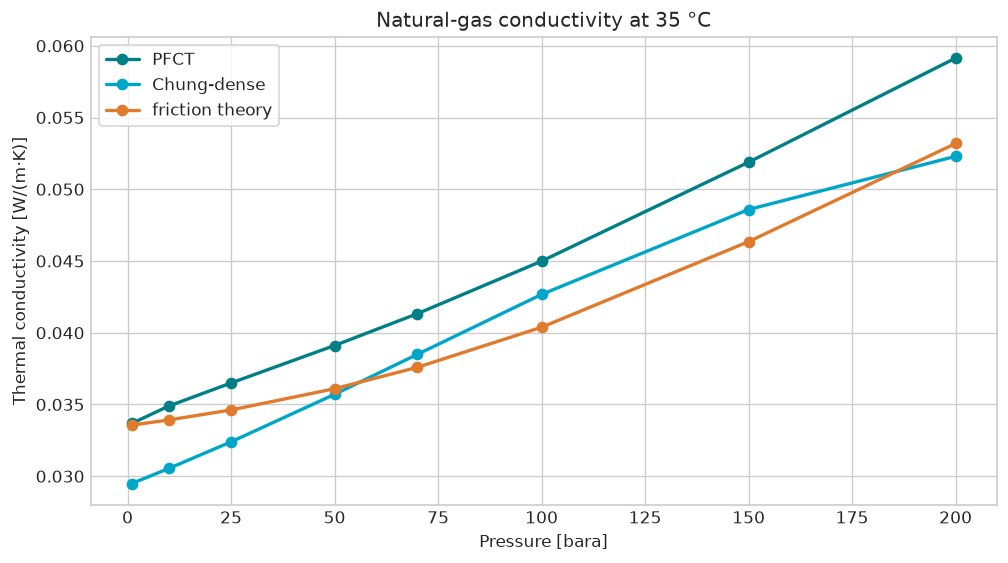

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for model in models:
    subset = pressure_df[pressure_df["model"] == model]
    ax.plot(subset["pressure_bara"], subset["k_W_mK"], marker="o", linewidth=2, label=model, color=COLORS[model])
ax.set(xlabel="Pressure [bara]", ylabel="Thermal conductivity [W/(m·K)]", title="Natural-gas conductivity at 35 °C")
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

## 8. Temperature sensitivity

For gases away from phase boundaries, conductivity commonly increases with temperature because molecular energy transport becomes more effective. The next sweep covers −20 to 80 °C at 70 bara. A smooth trend is expected; phase-boundary proximity would require additional diagnostics and should not be inferred from this single-phase study.

In [8]:
temperatures_C = np.array([-20, 0, 20, 35, 50, 65, 80], dtype=float)
temperature_rows = [
    gas_properties(t, 70.0, model=m)
    for m in models
    for t in temperatures_C
]
temperature_df = pd.DataFrame(temperature_rows)
temperature_pivot = temperature_df.pivot(index="temperature_C", columns="model", values="k_W_mK")
display(temperature_pivot.style.format("{:.5f}"))

model,Chung-dense,PFCT,friction theory
temperature_C,,,
-20.000000,0.03290,0.03821,0.03243
0.000000,0.03458,0.03870,0.03387
20.000000,0.03671,0.04003,0.03588
35.000000,0.03849,0.04133,0.03759
50.000000,0.04039,0.04281,0.03943
65.000000,0.04239,0.04445,0.04138
80.000000,0.04447,0.04620,0.04341


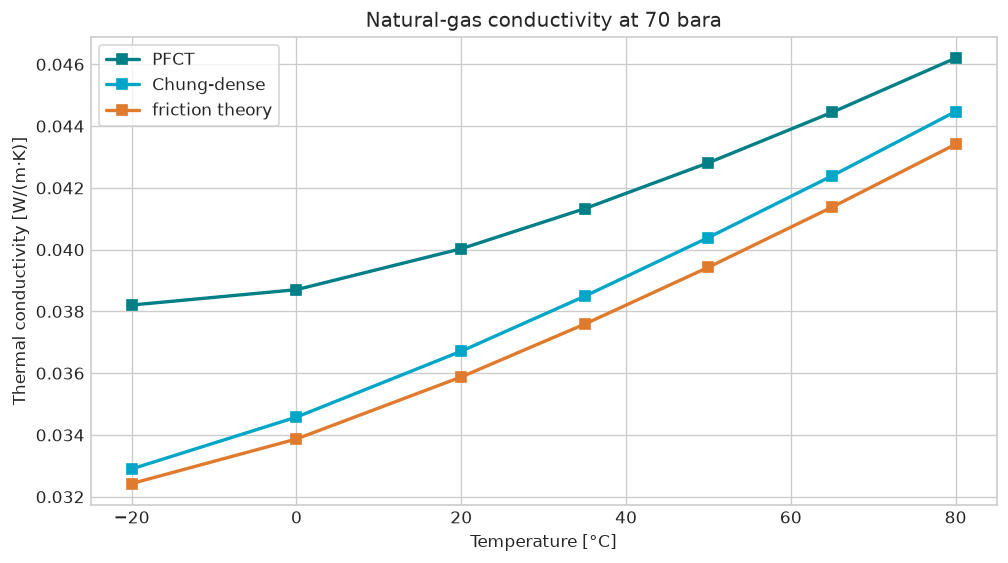

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for model in models:
    subset = temperature_df[temperature_df["model"] == model]
    ax.plot(subset["temperature_C"], subset["k_W_mK"], marker="s", linewidth=2, label=model, color=COLORS[model])
ax.set(xlabel="Temperature [°C]", ylabel="Thermal conductivity [W/(m·K)]", title="Natural-gas conductivity at 70 bara")
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

## 9. Engineering consequence: an internal convection estimate

To show why conductivity matters, consider fully developed turbulent flow in a straight circular pipe. For a preliminary screening calculation, the Dittus–Boelter form is

$$Nu=0.023Re^{0.8}Pr^{0.4},\qquad h=\frac{Nu\,k}{D},$$

with

$$Re=\frac{\rho vD}{\mu}.$$

The exponent 0.4 represents heating of the fluid. This correlation is not a replacement for a detailed exchanger or pipeline model: entrance effects, roughness, wall-property variation, fouling, two-phase flow, and validity limits must be considered in design work.

In [10]:
pipe_diameter_m = 0.30
gas_velocity_m_s = 8.0

heat_transfer_rows = []
for model in models:
    props = gas_properties(35.0, 70.0, model=model)
    reynolds = props["density_kg_m3"] * gas_velocity_m_s * pipe_diameter_m / props["viscosity_Pa_s"]
    nusselt = 0.023 * reynolds**0.8 * props["Pr"]**0.4
    h = nusselt * props["k_W_mK"] / pipe_diameter_m
    heat_transfer_rows.append({"model": model, "Re": reynolds, "Pr": props["Pr"], "Nu": nusselt, "h_W_m2K": h})

heat_transfer_df = pd.DataFrame(heat_transfer_rows)
display(heat_transfer_df.style.format({"Re": "{:.3e}", "Pr": "{:.3f}", "Nu": "{:.1f}", "h_W_m2K": "{:.1f}"}))

,model,Re,Pr,Nu,h_W_m2K
0,PFCT,1.024e+07,0.855,8762.3,1207.1
1,Chung-dense,1.024e+07,0.918,9014.9,1156.7
2,friction theory,1.024e+07,0.940,9100.9,1140.4


## 10. Reference-point checks

The current NeqSim conductivity regression tests cite approximate reference values of 0.0343 W/(m·K) for methane gas near 300 K and 1 bar, and 0.1232 W/(m·K) for liquid n-heptane near 300 K. These checks are intentionally broad screening comparisons, not independent experimental validation of every mixture and condition.

Pure-component states also verify that the phase-specific accessor is used correctly: methane is read from the gas phase and n-heptane from the oil phase.

In [11]:
def pure_component_k(component, temperature_C, pressure_bara, phase_name):
    system = fluid("srk")
    system.addComponent(component, 1.0)
    system.setMixingRule("classic")
    system.setTemperature(temperature_C, "C")
    system.setPressure(pressure_bara, "bara")
    TPflash(system)
    system.initProperties()
    return float(system.getPhase(phase_name).getThermalConductivity("W/mK"))

reference_rows = [
    {"case": "methane gas", "calculated": pure_component_k("methane", 26.85, 1.0, "gas"), "reference": 0.0343},
    {"case": "n-heptane liquid", "calculated": pure_component_k("n-heptane", 26.85, 10.0, "oil"), "reference": 0.1232},
]
reference_df = pd.DataFrame(reference_rows)
reference_df["relative_deviation_pct"] = 100.0 * (reference_df["calculated"] / reference_df["reference"] - 1.0)
display(reference_df.style.format({"calculated": "{:.5f}", "reference": "{:.5f}", "relative_deviation_pct": "{:+.1f}"}))

,case,calculated,reference,relative_deviation_pct
0,methane gas,0.03506,0.03430,+2.2
1,n-heptane liquid,0.11213,0.12320,-9.0


## 11. Composition scenarios

Composition changes molecular weight, heat capacity, density, viscosity, and conductivity together. Three synthetic scenarios illustrate this coupling: lean methane-rich gas, the base gas, and a richer gas with more ethane and propane. The comparison is made at the same 35 °C and 70 bara using PFCT.

The scenarios are not plant samples and should not be used as a substitute for a controlled compositional analysis.

In [12]:
composition_scenarios = {
    "lean": {"methane": 0.940, "ethane": 0.030, "propane": 0.010, "CO2": 0.010, "nitrogen": 0.010},
    "base": composition,
    "rich": {"methane": 0.800, "ethane": 0.120, "propane": 0.050, "CO2": 0.020, "nitrogen": 0.010},
}
scenario_rows = []
for scenario, z in composition_scenarios.items():
    assert math.isclose(sum(z.values()), 1.0, abs_tol=1e-12)
    row = gas_properties(35.0, 70.0, model="PFCT", z=z)
    row["scenario"] = scenario
    scenario_rows.append(row)
scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df[["scenario", "k_W_mK", "density_kg_m3", "cp_J_kgK", "Pr"]].style.format({
    "k_W_mK": "{:.5f}", "density_kg_m3": "{:.2f}", "cp_J_kgK": "{:.1f}", "Pr": "{:.3f}"
}))

,scenario,k_W_mK,density_kg_m3,cp_J_kgK,Pr
0,lean,0.04233,52.24,2661.5,0.833
1,base,0.04133,56.92,2647.5,0.855
2,rich,0.04023,64.00,2662.3,0.892


## 12. Numerical and physical validation gate

A result table is useful only if its assumptions and basic physics have been checked. The gate below requires finite positive properties, a gas-like Prandtl number, reproducible pressure and temperature trends, plausible model ranges, turbulent applicability for the example correlation, and reasonable agreement with the cited pure-component reference points.

Every check must pass before the notebook is considered successfully executed.

In [13]:
checks = {
    "composition closes to one": math.isclose(sum(composition.values()), 1.0, abs_tol=1e-12),
    "base conductivity finite and positive": np.isfinite(base["k_W_mK"]) and base["k_W_mK"] > 0.0,
    "base density, viscosity and Cp positive": all(base[key] > 0 for key in ["density_kg_m3", "viscosity_Pa_s", "cp_J_kgK"]),
    "gas Prandtl number plausible": 0.5 < base["Pr"] < 1.5,
    "all model predictions plausible": model_table["k_W_mK"].between(0.005, 0.5).all(),
    "PFCT conductivity rises across pressure sweep": np.all(np.diff(pressure_pivot["PFCT"].to_numpy()) > 0.0),
    "PFCT conductivity rises across temperature sweep": np.all(np.diff(temperature_pivot["PFCT"].to_numpy()) > 0.0),
    "all sensitivity outputs finite": np.isfinite(pressure_df["k_W_mK"]).all() and np.isfinite(temperature_df["k_W_mK"]).all(),
    "pipe example is turbulent": (heat_transfer_df["Re"] > 10_000).all(),
    "heat-transfer coefficients positive": (heat_transfer_df["h_W_m2K"] > 0.0).all(),
    "reference deviations below 20 percent": (reference_df["relative_deviation_pct"].abs() < 20.0).all(),
    "scenario outputs finite and positive": np.isfinite(scenario_df["k_W_mK"]).all() and (scenario_df["k_W_mK"] > 0.0).all(),
}
validation_df = pd.DataFrame({"check": checks.keys(), "passed": checks.values()})
display(validation_df)
assert all(checks.values()), validation_df.loc[~validation_df["passed"], "check"].tolist()

,check,passed
0,composition closes to one,True
1,base conductivity finite and positive,True
2,"base density, viscosity and Cp positive",True
3,gas Prandtl number plausible,True
4,all model predictions plausible,True
5,PFCT conductivity rises across pressure sweep,True
6,PFCT conductivity rises across temperature sweep,True
7,all sensitivity outputs finite,True
8,pipe example is turbulent,True
9,heat-transfer coefficients positive,True


## 13. Engineering interpretation, limitations, and applicability

The base-case models should be read as a bounded model comparison. If model spread materially affects exchanger area, cooldown time, or operating limits, the next step is comparison with suitable experimental data and a model selected for the actual phase, composition, and pressure–temperature range.

Important limitations:

- a cubic equation of state and conductivity correlation do not replace measured transport-property data;
- behavior near critical points and phase boundaries can be more sensitive than this grid suggests;
- water, brines, glycols, hydrogen, CO₂-rich fluids, refrigerants, and characterized oils may require dedicated physical-property models;
- two-phase systems require separate phase properties and a flow-regime-dependent heat-transfer treatment;
- the Dittus–Boelter calculation is a screening example with idealized geometry and constant bulk properties; and
- engineering design must include uncertainty, fouling, materials, mechanical constraints, operating envelopes, and applicable company/industry practices.

In [14]:
execution_summary = {
    "status": "PASS",
    "neqsim_version": neqsim_version,
    "base_state": {"temperature_C": 35.0, "pressure_bara": 70.0},
    "base_k_W_mK": round(base["k_W_mK"], 6),
    "models_compared": models,
    "pressure_points": len(pressures_bara),
    "temperature_points": len(temperatures_C),
    "validation_checks_passed": int(sum(checks.values())),
    "validation_checks_total": len(checks),
}
print(execution_summary)

{'status': 'PASS', 'neqsim_version': '3.16.0', 'base_state': {'temperature_C': 35.0, 'pressure_bara': 70.0}, 'base_k_W_mK': 0.041329, 'models_compared': ['PFCT', 'Chung-dense', 'friction theory'], 'pressure_points': 8, 'temperature_points': 7, 'validation_checks_passed': 12, 'validation_checks_total': 12}


## 14. Documentation and practical exercises

Documentation used:

- [NeqSim thermal-conductivity models](https://equinor.github.io/neqsim/physical_properties/thermal_conductivity_models)
- [NeqSim physical-properties package](https://equinor.github.io/neqsim/physical_properties/)
- [NeqSim documentation home](https://equinor.github.io/neqsim/)
- [NeqSim fluid-mechanics heat-transfer documentation](https://equinor.github.io/neqsim/fluidmechanics/heat_transfer)

Suggested exercises:

1. Replace the synthetic gas with a documented fluid and repeat the model comparison.
2. Add a grid that approaches a phase boundary and record phase count at every point.
3. Compare pure CO₂ using the documented CO₂-specific conductivity model.
4. Propagate model spread through a simple exchanger-area calculation.
5. Replace the screening correlation with a NeqSim pipe or heat-exchanger model and compare results.

When reporting results, retain the runtime record, fluid definition, model name, units, validity checks, and limitations so another engineer can reproduce the calculation.